# Titanic Dataset — Mini EDA

### Objective
Perform a deeper Exploratory Data Analysis (EDA) on the Titanic dataset using:
- Better data cleaning (imputation)
- Deeper groupby analysis
- Advanced visualizations

**Tools used:** Python, Pandas, Seaborn, Matplotlib

## Step 1: Import Libraries
Importing all necessary libraries for data analysis and visualization.

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
print("Libraries ready!")

Libraries ready!


## Step 2: Load the Dataset
Loading the Titanic dataset directly from Seaborn's built-in collection.

In [10]:
df = sns.load_dataset('titanic')
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Dataset loaded — 891 passengers × 15 columns.

## Step 3: Clean the Data
Handling missing values using imputation strategies:

| Column | Strategy | Reason |
|--------|----------|--------|
| **age** | Fill with mean | Standard imputation technique |
| **deck** | Drop | 77% missing, unusable |

We also engineer a new feature — **Family Size** — by combining SibSp and Parch.

In [11]:
df['age'] = df['age'].fillna(df['age'].mean())
print(f"Age mean: {df['age'].mean():.2f}")

Age mean: 29.70


In [12]:
df.drop(columns=['deck', 'embark_town', 'who', 'adult_male', 'alive', 'alone'], inplace=True)
print("Columns remaining:", list(df.columns))

Columns remaining: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class']


In [13]:
df['family_size'] = df['sibsp'] + df['parch']
print(df['family_size'].value_counts())

family_size
0     537
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64


In [14]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
family_size,0


Data is clean and a new feature (family_size) has been created!

## Step 4: Deeper Analysis

### Q1: Did Embarkation Port affect survival?
The 3 ports — Southampton (S), Cherbourg (C), Queenstown (Q)

In [15]:
df.groupby('embarked')['survived'].mean()

,survived
embarked,
C,0.553571
Q,0.389610
S,0.336957


Cherbourg (55%) had the highest survival rate.
This is because Cherbourg passengers were mostly wealthy 1st class travelers.
Port itself didn't cause survival — wealth hidden behind it did!

### Q2: Did Family Size affect survival?
We created this feature ourselves: Family Size = SibSp + Parch

In [16]:
df.groupby('family_size')['survived'].mean()

,survived
family_size,
0,0.303538
1,0.552795
2,0.578431
3,0.724138
4,0.200000
5,0.136364
6,0.333333
7,0.000000
10,0.000000


Family size of 3 had the best survival rate (72%).
Solo travelers and very large families had the worst chances.
The pattern forms an upside-down U shape — small families helped each other most.

### Q3: Survival rate by Age Group?
Passengers are grouped into 5 age categories for analysis.

In [17]:
bins   = [0, 12, 18, 30, 50, 80]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
df.groupby('age_group', observed=True)['survived'].mean()

,survived
age_group,
Child,0.579710
Teen,0.428571
Young Adult,0.331096
Adult,0.423237
Senior,0.343750


Children (58%) had the highest survival rate.
Survival generally declined with age due to evacuation priorities.

## Step 5: Visualizations
Three charts that tell the complete story of this EDA.

### Chart 1: Age Distribution
A histogram showing the spread of passenger ages with mean marked.

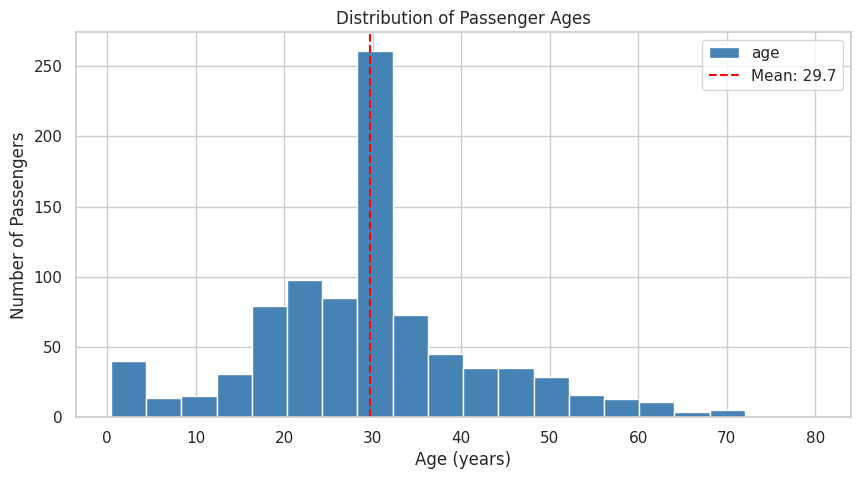

In [18]:
plt.figure(figsize=(10, 5))
df['age'].plot(kind='hist', bins=20, color='steelblue', edgecolor='white')
plt.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df["age"].mean():.1f}')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age (years)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

Most passengers were young adults (20–35).
Notice the tall bar at ~29 — that's the impact of filling missing values with the mean!

###  Chart 2: Correlation Heatmap
Shows how strongly each pair of variables is related.
- Values close to 1 = strong positive relationship
- Values close to -1 = strong negative relationship
- Values close to 0 = no relationship

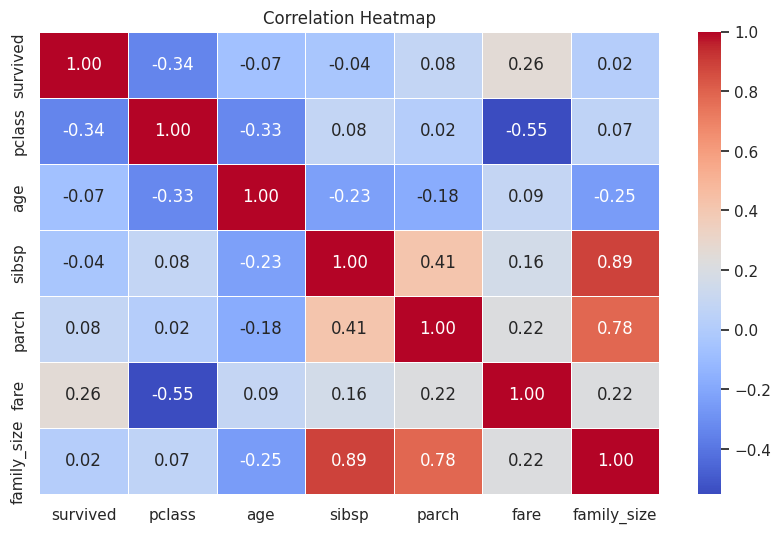

In [19]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Key correlations found:
- pclass vs fare: -0.55 (higher class = more expensive ticket)
- survived vs pclass: -0.34 (higher class number = lower survival)
- sibsp vs family_size: 0.89 (obviously related — we built family_size from sibsp!)

### Chart 3: Survival by Family Size
A bar chart showing how traveling alone vs with family affected survival.

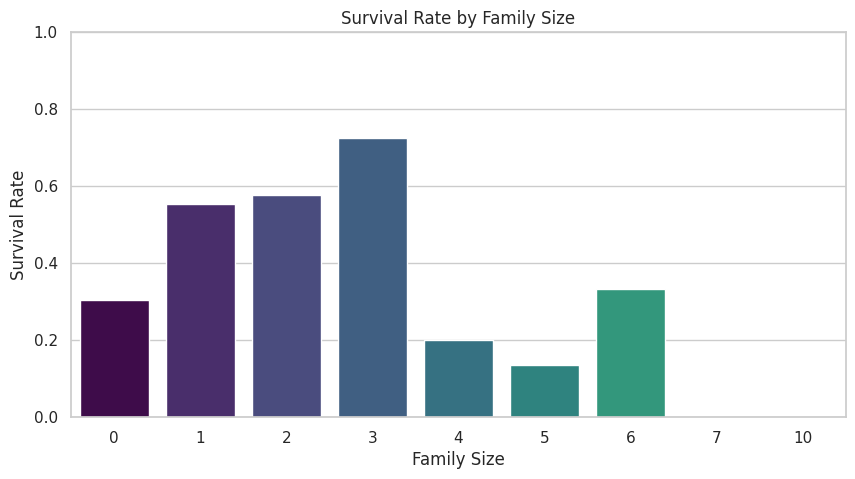

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(x='family_size', y='survived', data=df,
            hue='family_size', palette='viridis',
            errorbar=None, legend=False)
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

The upside-down U shape is clearly visible!
Small families (1–3) had the best survival.
Solo travelers and large families struggled the most.

## Conclusion

### Key Findings from this EDA:

| Question | Finding |
|----------|---------|
| Embarkation Port | Cherbourg passengers survived most (55%) |
| Family Size | Size of 3 had best survival (72%) |
| Age Group | Children had highest survival (58%) |

### What made this EDA deeper:
- Used **mean imputation** for missing Age values
- **Engineered a new feature** (family_size) from existing columns
- Discovered that port survival is actually driven by **hidden wealth patterns**
- Used a **correlation heatmap** to see relationships between all variables at once

### What I learned:
- EDA is about asking the right questions
- One variable can hide another variable behind it
- Feature engineering creates new insights from existing data
- Visualizations make patterns impossible to miss
